# EDA — The evaluation datasets

Two evaluation data sources feed the study's three evaluation notebooks:

**1. MentalChat16K test split** — scores the fine-tuning itself
(`evaluate_metric` + `evaluate_llm_judge`). The prior `mhsupportchat` study
evaluated on this corpus too, with a different split:

| | prior study (mhsupportchat) | this study |
|---|---|---|
| **Source** | `ShenLab/MentalChat16K` (HuggingFace) | same corpus, pinned revision |
| **Cleaning** | dedupe only | dedupe + quality filters (placeholder / letter / >700-word rows dropped) |
| **Split** | row-level 70/20/10, seed 42 → `data/test.csv` (1,598 rows) | grouped by user text 70/20/10, seed 42 — no question can appear in two splits |
| **Evaluation set** | the full test csv | the test split, grouped to unique questions with multi-references (`evaluator.testbed()`) |

**2. Multi-turn CounselChat** (`Jingy2000/multi-turn-counsel-chat`) — the
single-vs-multi architecture evaluation (`evaluate_single_vs_multi`): real
CounselChat.com Q&A expanded into client/counselor dialogues with GPT-4.
Multi-turn is required there because the architectures only diverge with
history (verbatim vs summarizer memory). The seeded cases are previewed at
the bottom.


In [1]:
# Setup
import os
os.environ["PYTHONUTF8"] = "1"

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))               # ft root (ft_utils, config)
sys.path.insert(0, str(Path.cwd().parent / "evaluate"))  # evaluator, single_vs_multi

import json

import matplotlib.pyplot as plt
import pandas as pd

import evaluator
import ft_utils

train_df, val_df, test_df = ft_utils.load_and_split("mentalchat16k")
bed = evaluator.testbed()
print(f"MentalChat16K splits: train {len(train_df)} / val {len(val_df)} / test {len(test_df)}")
print(f"testbed: {len(bed)} unique questions, "
      f"{(bed['refs'].str.len() > 1).sum()} with multiple references")


MentalChat16K splits: train 10383 / val 2966 / test 1483
testbed: 1470 unique questions, 7 with multiple references


In [2]:
# The prior study's evaluation csv (row-level split of the same corpus)
OLD_TEST = Path(r"C:\Users\laoli\OneDrive\Desktop\multi agent mental health chat\mhsupportchat\data\test.csv")
if OLD_TEST.exists():
    old_df = pd.read_csv(OLD_TEST)
    old_q = set(old_df["input"].astype(str).str.strip())
    print(f"prior study test.csv: {len(old_df)} rows, {len(old_q)} unique questions")
    overlap_test = old_q & set(bed["input"])
    overlap_train = old_q & set(train_df["input"])
    print(f"overlap with THIS study's test questions:  {len(overlap_test)}")
    print(f"overlap with THIS study's TRAIN questions: {len(overlap_train)} "
          "<- why scores are not comparable across the two studies")
else:
    print("prior study csv not found on this machine — comparison skipped")


prior study test.csv: 1598 rows, 1594 unique questions
overlap with THIS study's test questions:  127
overlap with THIS study's TRAIN questions: 1040 <- why scores are not comparable across the two studies


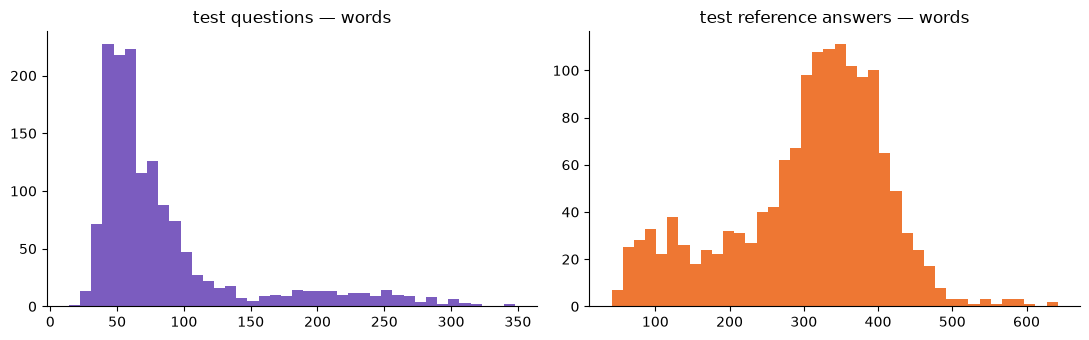

count    1483.0
mean      305.2
std       105.0
min        41.0
25%       251.0
50%       325.0
75%       378.5
max       642.0


In [3]:
# Length distributions of the MentalChat16K test questions / references
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(test_df["input"].str.split().str.len(), bins=40, color="#7B5CBF")
axes[0].set_title("test questions — words")
axes[1].hist(test_df["output"].str.split().str.len(), bins=40, color="#EE7733")
axes[1].set_title("test reference answers — words")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print(test_df["output"].str.split().str.len().describe().round(1).to_string())


In [4]:
# Multi-turn CounselChat: the whole corpus, then the seeded replay cases
import single_vs_multi as svm

data = json.loads(svm.RAW_PATH.read_text(encoding="utf-8"))
n_client = pd.Series([sum(1 for m in d["messages"] if m["role"] == "client")
                      for d in data])
print(f"{len(data)} conversations | client turns per conversation:")
print(n_client.describe().round(1).to_string())

cases = svm.load_cases()
tasks = svm.flat_turns(cases)
print(f"\nseeded replay: {len(cases)} cases (seed {ft_utils.SEED}), "
      f"{len(tasks)} client turns, cap {svm.MAX_CLIENT_TURNS}/case\n")
for c in cases:
    first = c["turns"][0]["message"] if c["turns"] else "(empty)"
    print(f"case {c['case']:>3} | {len(c['turns'])} turns | {first[:80]}")


863 conversations | client turns per conversation:
count    863.0
mean       7.6
std        1.0
min        5.0
25%        7.0
50%        8.0
75%        8.0
max       11.0

seeded replay: 10 cases (seed 42), 60 client turns, cap 6/case

case  25 | 6 turns | I've been feeling really upset and confused lately. Something happened at a frie
case 104 | 6 turns | I'm doing okay, thanks. I've been thinking about something and hoped I could get
case 114 | 6 turns | Honestly, I've been better. I'm going through a divorce, and it's been extremely
case 142 | 6 turns | Honestly, not great. I constantly feel like everyone is against me and it's real
case 228 | 6 turns | Honestly, I've been better. I just feel like I'm stuck in a rut. I spend all my 
case 250 | 6 turns | Honestly, not great. I've been having horrendous nightmares this whole month, an
case 281 | 6 turns | Not great, to be honest. I've been struggling with major depression, severe PTSD
case 654 | 6 turns | Honestly, not great. I'm feel

In [5]:
# One full replay case, as both systems will see it unfold
c = cases[0]
for t in c["turns"][:3]:
    print(f"--- turn {t['turn']} (history: {len(t['history'])} exchanges) ---")
    print(f"CLIENT:    {t['message'][:160]}")
    print(f"REFERENCE: {t['reference'][:160]}")
    print()


--- turn 0 (history: 0 exchanges) ---
CLIENT:    I've been feeling really upset and confused lately. Something happened at a friend's house that's been bothering me a lot.
REFERENCE: I'm truly sorry to hear that you're going through a difficult time. It's important that you know you're not alone. Would you feel comfortable sharing more about

--- turn 1 (history: 1 exchanges) ---
CLIENT:    Yeah, I think I need to talk about it. We were just hanging out, having some drinks and watching TV. Then, I started feeling sick. My friend went to bed, but ca
REFERENCE: It sounds like you were in a vulnerable state, and it was good that initially, your friend showed concern for your well-being. What happened after you said you 

--- turn 2 (history: 2 exchanges) ---
CLIENT:    He suggested I lay down for a bit. But after I did, he started touching me in a way I didn't consent to. I was really scared and didn't know what to do.
REFERENCE: I am so sorry that you experienced that. It's completely un